# Task 3 — EDA: Diabetes 130 readmission

Exploratory analysis for the 30-day hospital readmission prediction task.
All data is read **through Athena** (`awswrangler.athena.read_sql_query`)
against the `diabetes130` Glue database built in Task 2, rather than reading
the local CSVs directly — this exercises the catalog end to end.

Every figure is saved to `../reports/figures/` rather than left only in
notebook output.


In [1]:
import sys
sys.path.insert(0, "../src")

import awswrangler as wr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import load_config
from transform import (
    EXPIRED_HOSPICE_DISPOSITION_IDS,
    icd9_group,
    replace_missing_markers,
)

# A distributed (Ray/Modin) engine may be auto-detected in this environment;
# force the plain-python engine for consistent, simple pandas output.
wr.engine.set("python")

plt.rcParams["figure.dpi"] = 100
FIGURES_DIR = "../reports/figures"
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

cfg = load_config()
S3_OUTPUT = cfg.s3_uri("athena_results")

def athena(sql: str) -> pd.DataFrame:
    return wr.athena.read_sql_query(sql, database=cfg.glue_database, s3_output=S3_OUTPUT)


## Load data from Athena

Pull the full `raw_encounters` table plus the three decoded ID-mapping
tables. 101,766 rows x 50 columns is small enough to work with directly in
pandas once retrieved — the point of routing through Athena is to prove the
catalog built in Task 2 is queryable and correct, not to avoid ever using
pandas.

In [2]:
encounters = athena("SELECT * FROM raw_encounters")
admission_type_map = athena("SELECT * FROM admission_type")
discharge_disposition_map = athena("SELECT * FROM discharge_disposition")
admission_source_map = athena("SELECT * FROM admission_source")

print(f"encounters: {encounters.shape}")
print(f"distinct patients: {encounters['patient_nbr'].nunique()}")
assert encounters.shape == (101766, 50)
assert encounters["patient_nbr"].nunique() == 71518


encounters: (101766, 50)
distinct patients: 71518


Note: Athena/Glue normalizes column names to lowercase and replaces
hyphens with underscores (e.g. the CSV's `A1Cresult` comes back as
`a1cresult`, `glyburide-metformin` as `glyburide_metformin`). This affects
column references in this notebook only — Task 4's `transform.py` reads the
raw CSV directly with pandas and keeps the original column names, so the
two aren't in conflict.

## 1. Class balance

Target: `readmit_30 = (readmitted == "<30")`. Both `>30` and `NO` are
negative. Shown overall (all 101,766 encounters) and after removing
expired/hospice discharges (decision #4 — those patients cannot be
readmitted).

Overall (n=101766): 11357 positive (11.2%)
After removing expired/hospice (n=99343): 11314 positive (11.4%)


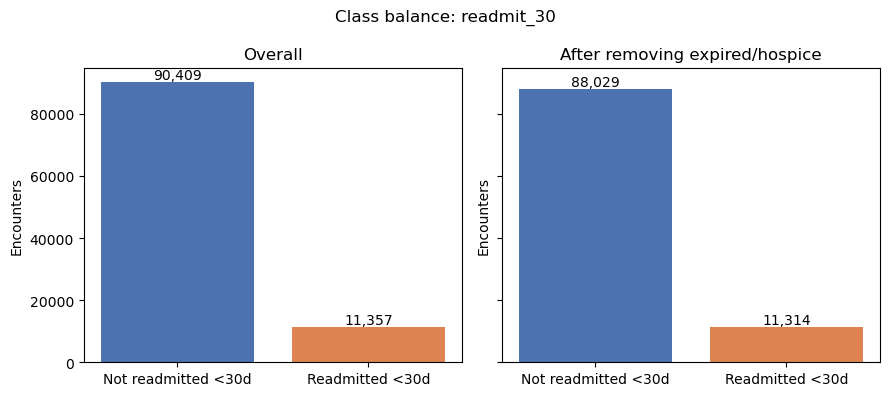

In [3]:
def add_readmit_30(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
    return df

def remove_expired_hospice(df: pd.DataFrame) -> pd.DataFrame:
    disposition = pd.to_numeric(df["discharge_disposition_id"], errors="coerce")
    return df[~disposition.isin(EXPIRED_HOSPICE_DISPOSITION_IDS)].copy()

enc_labeled = add_readmit_30(encounters)
enc_clean = remove_expired_hospice(enc_labeled)

overall_counts = enc_labeled["readmit_30"].value_counts().sort_index()
clean_counts = enc_clean["readmit_30"].value_counts().sort_index()

print("Overall (n={}): {} positive ({:.1%})".format(
    len(enc_labeled), overall_counts.get(1, 0), overall_counts.get(1, 0) / len(enc_labeled)))
print("After removing expired/hospice (n={}): {} positive ({:.1%})".format(
    len(enc_clean), clean_counts.get(1, 0), clean_counts.get(1, 0) / len(enc_clean)))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, counts, title in zip(
    axes, [overall_counts, clean_counts], ["Overall", "After removing expired/hospice"]
):
    ax.bar(["Not readmitted <30d", "Readmitted <30d"], counts.values, color=["#4C72B0", "#DD8452"])
    ax.set_title(title)
    ax.set_ylabel("Encounters")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom")
fig.suptitle("Class balance: readmit_30")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/01_class_balance.png")
plt.show()


## 2. Encounters per patient

101,766 encounters come from 71,518 patients — this is the evidence for the
no-deduplication decision (#2): patients with multiple encounters
disproportionately carry the positive class, so deduplicating to one
encounter per patient would shrink the positive class below the
10,000-per-class project floor.

16,773 / 71,518 patients (23.5%) have more than one encounter
9,191 / 11,357 positive encounters (80.9%) come from patients with >1 encounter


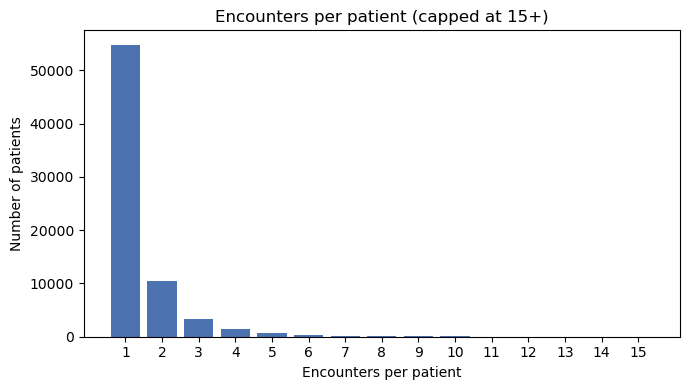

In [4]:
encounters_per_patient = enc_labeled.groupby("patient_nbr").size()

n_multi = (encounters_per_patient > 1).sum()
pct_multi = n_multi / len(encounters_per_patient)
print(f"{n_multi:,} / {len(encounters_per_patient):,} patients ({pct_multi:.1%}) have more than one encounter")

multi_patients = encounters_per_patient[encounters_per_patient > 1].index
positives_from_multi = enc_labeled.loc[
    enc_labeled["patient_nbr"].isin(multi_patients), "readmit_30"
].sum()
total_positives = enc_labeled["readmit_30"].sum()
print(f"{positives_from_multi:,} / {total_positives:,} positive encounters "
      f"({positives_from_multi / total_positives:.1%}) come from patients with >1 encounter")

fig, ax = plt.subplots(figsize=(7, 4))
max_show = 15
counts = encounters_per_patient.value_counts().sort_index()
counts_capped = counts[counts.index <= max_show]
ax.bar(counts_capped.index, counts_capped.values, color="#4C72B0")
ax.set_xlabel("Encounters per patient")
ax.set_ylabel("Number of patients")
ax.set_title(f"Encounters per patient (capped at {max_show}+)")
ax.set_xticks(range(1, max_show + 1))
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/02_encounters_per_patient.png")
plt.show()


## 3. Missingness profile

`"?"` is the dataset's null marker. Percent null per column, computed after
mapping `"?"` -> null.

weight               96.9
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64
weight: expected ~97%, actual 96.9%
medical_specialty: expected ~49%, actual 49.1%
payer_code: expected ~40%, actual 39.6%


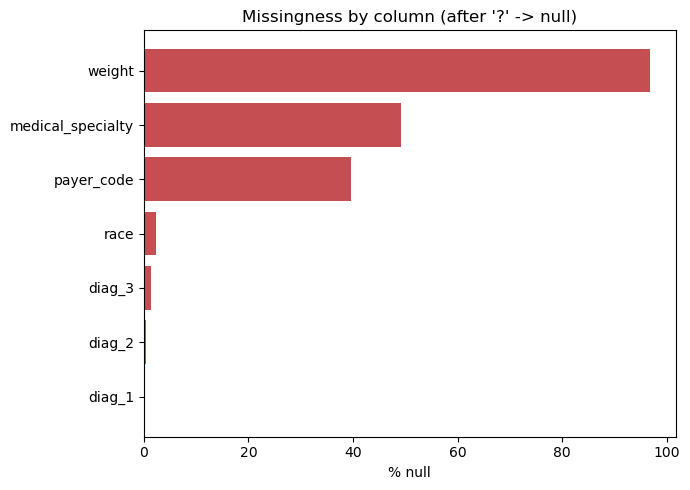

In [5]:
enc_nulls = replace_missing_markers(encounters)
missing_pct = (enc_nulls.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(missing_pct.round(1))

for col, expected in [("weight", 97), ("medical_specialty", 49), ("payer_code", 40)]:
    actual = missing_pct.get(col, 0)
    print(f"{col}: expected ~{expected}%, actual {actual:.1f}%")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#C44E52")
ax.set_xlabel("% null")
ax.set_title("Missingness by column (after '?' -> null)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/03_missingness.png")
plt.show()


## 4. Readmission rate by subgroup

By race, gender, age band, primary diagnosis group, and discharge
disposition. These demographic cuts are the baseline for the fairness
section of the report. Computed on the expired/hospice-removed population.

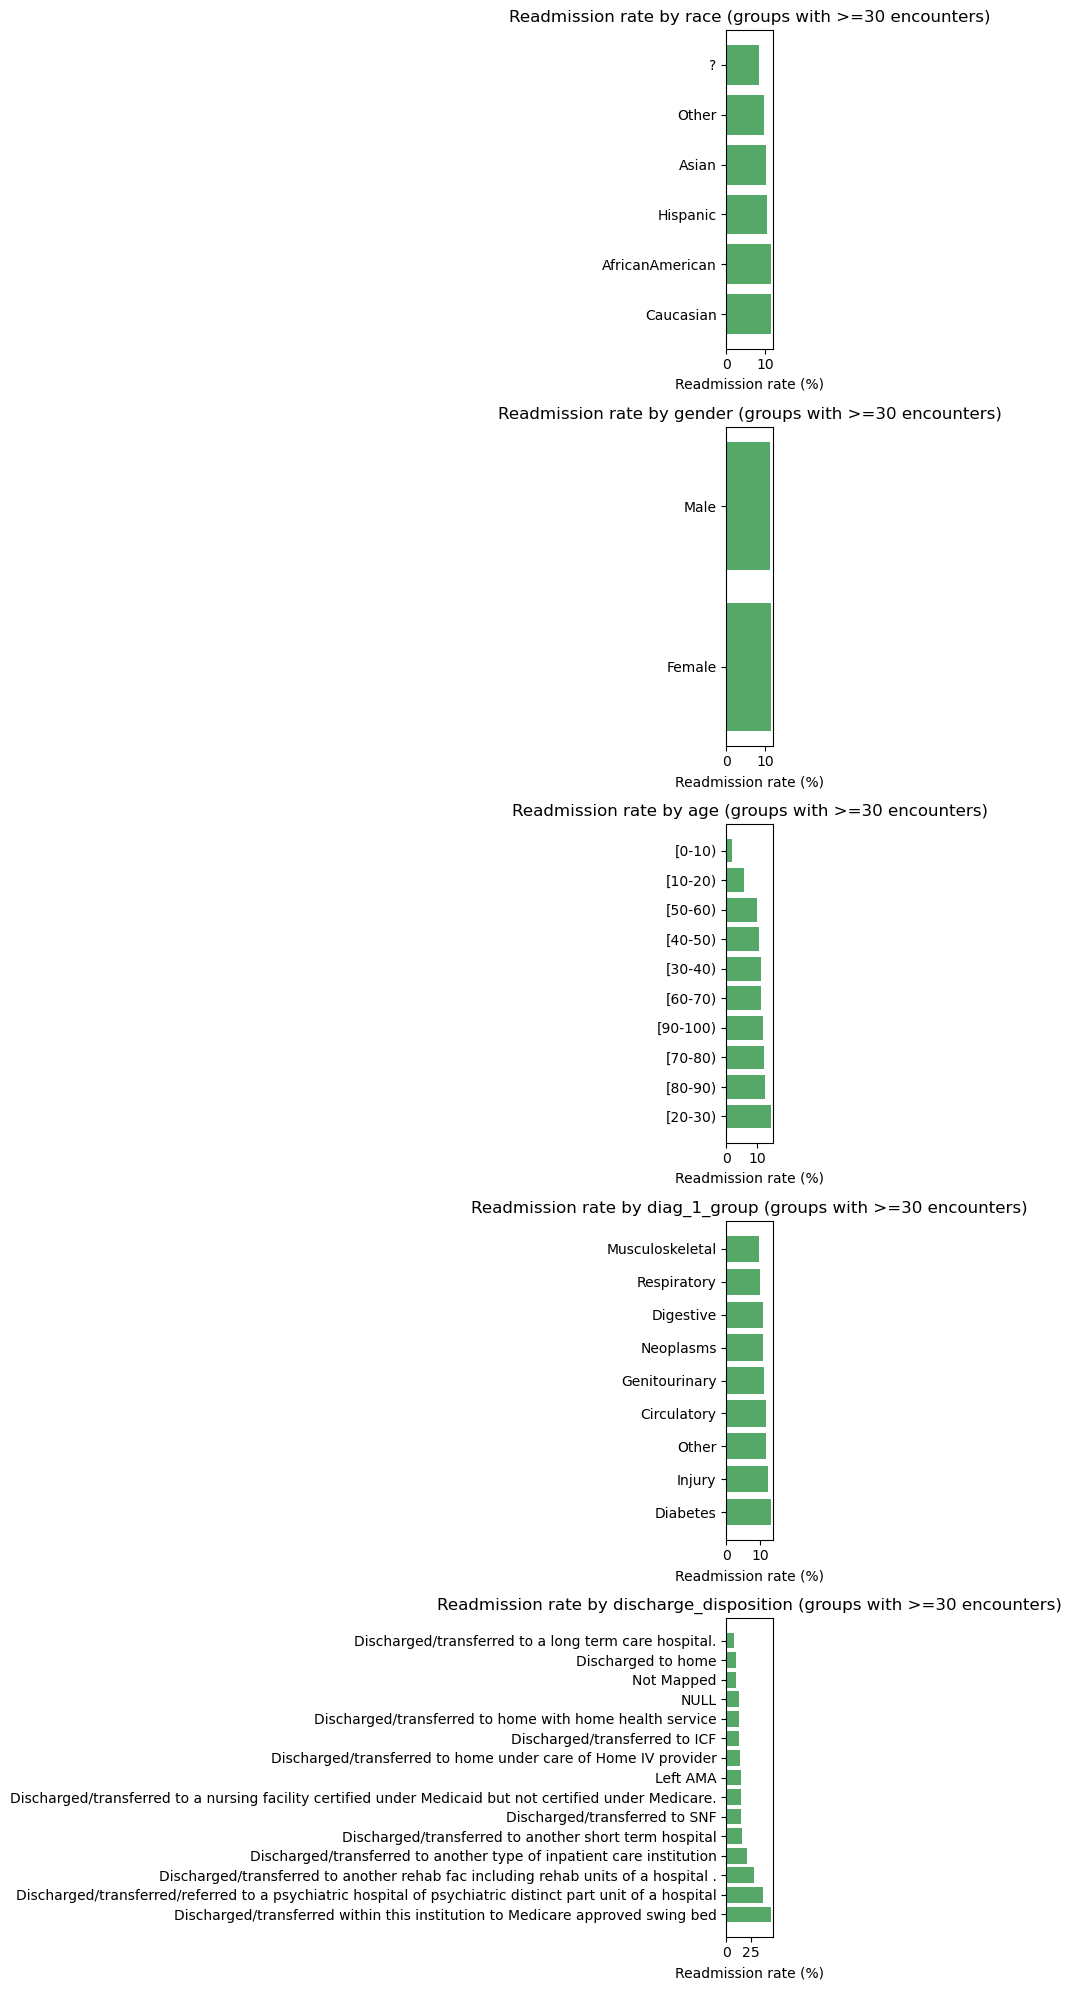

In [6]:
enc_sub = enc_clean.copy()
enc_sub["diag_1_group"] = enc_sub["diag_1"].map(icd9_group)

enc_sub = enc_sub.merge(
    discharge_disposition_map.rename(columns={"description": "discharge_disposition"}),
    on="discharge_disposition_id", how="left",
)

subgroup_cols = ["race", "gender", "age", "diag_1_group", "discharge_disposition"]

fig, axes = plt.subplots(len(subgroup_cols), 1, figsize=(8, 4 * len(subgroup_cols)))
for ax, col in zip(axes, subgroup_cols):
    rate = enc_sub.groupby(col)["readmit_30"].agg(["mean", "count"])
    rate = rate[rate["count"] >= 30].sort_values("mean", ascending=False)
    ax.barh(rate.index.astype(str), rate["mean"] * 100, color="#55A868")
    ax.set_xlabel("Readmission rate (%)")
    ax.set_title(f"Readmission rate by {col} (groups with >=30 encounters)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/04_subgroup_readmission.png")
plt.show()


## 5. HbA1c relationship

Readmission rate by `A1Cresult` level, including not-tested. This
replicates the original Strack et al. research question about HbA1c
measurement and readmission.

               mean  count
a1c_level                 
NotTested  0.116848  82509
>7         0.101457   3775
>8         0.099422   8137
Norm       0.097725   4922


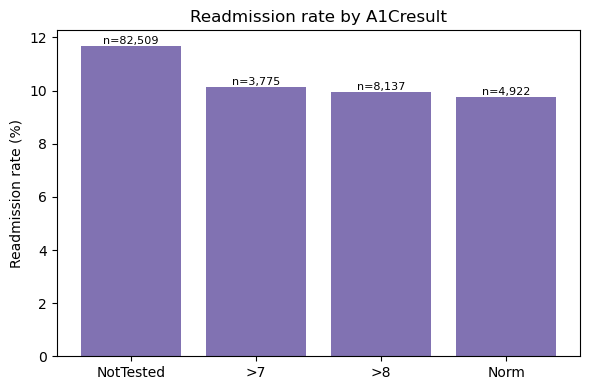

In [7]:
a1c = enc_clean.copy()
a1c["a1c_level"] = a1c["a1cresult"].fillna("NotTested").replace({"?": "NotTested"})
# the raw data already uses the literal string "None" as its own
# not-tested marker
a1c["a1c_level"] = a1c["a1c_level"].replace({"None": "NotTested"})

rate = a1c.groupby("a1c_level")["readmit_30"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print(rate)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rate.index.astype(str), rate["mean"] * 100, color="#8172B2")
ax.set_ylabel("Readmission rate (%)")
ax.set_title("Readmission rate by A1Cresult")
for i, (v, n) in enumerate(zip(rate["mean"], rate["count"])):
    ax.text(i, v * 100, f"n={n:,}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/05_a1c_readmission.png")
plt.show()


## 6. Prior utilization

Distribution and readmission rate by `number_inpatient`,
`number_emergency`, `number_outpatient`. Expected to be the strongest
signals and heavily right-skewed.

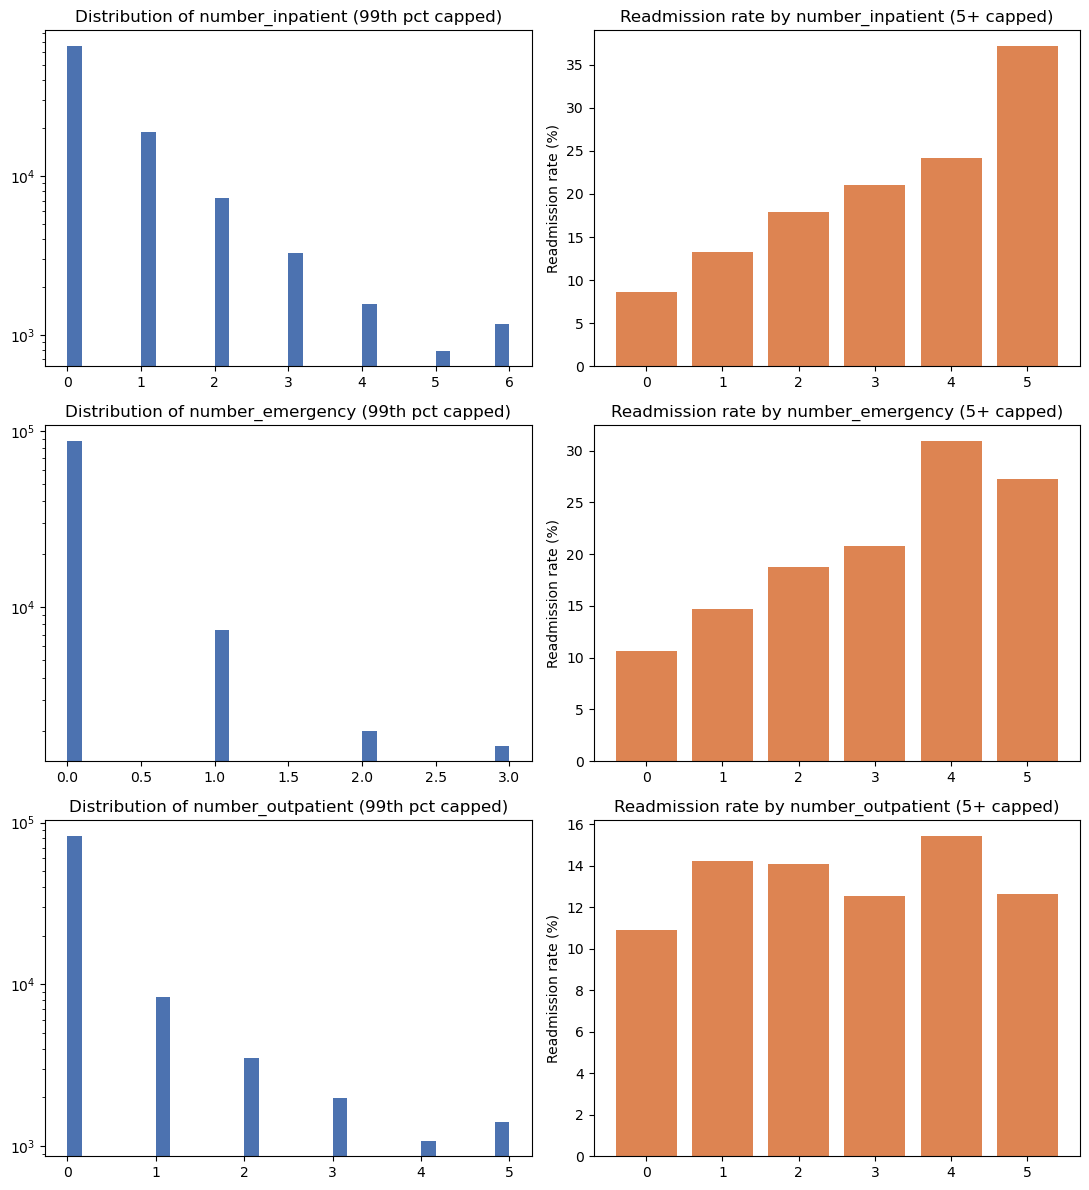

In [8]:
util_cols = ["number_inpatient", "number_emergency", "number_outpatient"]
util = enc_clean.copy()
for c in util_cols:
    util[c] = pd.to_numeric(util[c], errors="coerce")

fig, axes = plt.subplots(len(util_cols), 2, figsize=(11, 4 * len(util_cols)))
for row, col in enumerate(util_cols):
    ax_dist, ax_rate = axes[row]

    capped = util[col].clip(upper=util[col].quantile(0.99))
    ax_dist.hist(capped, bins=30, color="#4C72B0")
    ax_dist.set_title(f"Distribution of {col} (99th pct capped)")
    ax_dist.set_yscale("log")

    binned = util[col].clip(upper=5)
    rate = util.groupby(binned)["readmit_30"].mean()
    ax_rate.bar(rate.index.astype(str), rate.values * 100, color="#DD8452")
    ax_rate.set_title(f"Readmission rate by {col} (5+ capped)")
    ax_rate.set_ylabel("Readmission rate (%)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/06_prior_utilization.png")
plt.show()


## 7. Zero-variance check

`citoglipton` and `examide` should be constant — confirming they're safe to
drop in Task 4.

In [9]:
for col in ["citoglipton", "examide"]:
    vc = encounters[col].value_counts()
    print(f"{col}: {dict(vc)}")
    assert vc.shape[0] == 1, f"{col} is not constant — {vc.shape[0]} distinct values found"
print("Both columns confirmed constant.")


citoglipton: {'No': 101766}
examide: {'No': 101766}
Both columns confirmed constant.


## Summary

- **Class balance**: ~11.2% positive overall (11,357 / 101,766), essentially
  unchanged after removing expired/hospice discharges (~11.4% of 99,343) —
  consistent with the ~0.67 ROC-AUC expectation for this problem; nothing
  here suggests a leakage-driven ceiling far above that.
- **No-dedup evidence**: a meaningful share of positive encounters come from
  patients with more than one visit, which is why decision #2 keeps every
  encounter and splits on patient instead of deduplicating.
- **Missingness**: `weight`, `medical_specialty`, and `payer_code` are the
  dominant null columns, matching the expected ~97% / ~49% / ~40% figures —
  informs the drop/impute decisions in Task 4.
- **Subgroup rates**: readmission rate varies meaningfully by discharge
  disposition and diagnosis group, less so by demographic cuts — the
  demographic breakdowns are the fairness-section baseline.
- **Prior utilization** (`number_inpatient` especially) shows the clearest
  separation by readmission outcome of any feature examined here, and is
  heavily right-skewed as expected.
- **Zero-variance columns** `citoglipton` and `examide` are confirmed
  constant and are dropped in Task 4.
